<a href="https://colab.research.google.com/github/stephenkeyy77/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/Econ_3916_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

Step 1.1: The Zero-Inflated Gig Economy Tip Distribution

In [2]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

Step 1.2: The Manual Bootstrap Engine

In [3]:
n_simulated = 10000
medians = []
for i in range (n_simulated):
  samples = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
  medians.append(np.median(samples))
medians = np.array(medians)

ci_low = np.percentile(medians, 2.5)
ci_high = np.percentile(medians, 97.5)

print(f"The bootstrap median is {np.median(driver_tips)}")
print(f"The 95% confidence interval is ({ci_low}, {ci_high}).")

The bootstrap median is 0.7553316913699188
The 95% confidence interval is (0.2653018357387816, 1.3635639228066991).


Step 2.1: The Algorithmic Routing Crash

In [4]:
np.random.seed(42)
control   = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

obs_diff = np.mean(control) - np.mean(treatment)
print("The observed simple difference in means:", obs_diff)

The observed simple difference in means: 2.2649821306257394


Step 2.2: The Exact Non-Parametric Permutation

In [5]:
np.random.seed(42)
combined_data = np.concatenate([control,treatment])

simulated_diff = []
for i in range (5000):
  permuted_data = np.random.permutation(combined_data)
  group_a = permuted_data[500:]
  group_b = permuted_data[:500]
  simulated_diff.append(np.mean(group_a) - np.mean(group_b))
simulated_diff = np.array(simulated_diff)
obs_diff = np.mean(control) - np.mean(treatment)
count = np.sum(np.abs(simulated_diff) >= np.abs(obs_diff))
p_value = count / 5000
print(f"Empirical p-value is: {p_value:.4f}")


Empirical p-value is: 0.0004


Step 3.1: The Loyalty Program Paradox

In [8]:
df = pd.read_csv("swiftcart_loyalty.csv")
naive_diff = df[df['subscriber'] == 1]['post_spend'].mean() - df[df['subscriber'] == 0]['post_spend'].mean()
print(f"Naive Difference in Means: ${naive_diff:,.2f}")

Naive Difference in Means: $17.57


In [10]:
df.describe()

,subscriber,pre_spend,account_age,support_tickets,post_spend
count,8941.000000,8941.000000,8941.000000,8941.000000,8941.000000
mean,0.469746,49.968452,29.855945,0.997651,64.726670
std,0.499112,15.128037,17.126299,1.005630,15.336307
min,0.000000,-7.549833,1.000000,0.000000,16.091294
25%,0.000000,39.842574,15.000000,0.000000,54.175661
50%,0.000000,49.942938,30.000000,1.000000,64.720791
75%,1.000000,60.097720,45.000000,2.000000,75.379513
max,1.000000,108.893566,59.000000,7.000000,120.955374


Step 3.2: Propensity Score Matching (PSM) Architecture

In [16]:
from sklearn.linear_model import LogisticRegression
X = df[['pre_spend', 'account_age', 'support_tickets']]
Y = df['subscriber']

logit = LogisticRegression(solver='liblinear')
logit.fit(X, Y)

df['pscore'] = logit.predict_proba(X)[:, 1]

df[['subscriber', 'pscore']].head()

,subscriber,pscore
0,1,0.545499
1,1,0.548858
2,1,0.683188
3,1,0.778225
4,1,0.397873


In [22]:
from sklearn.neighbors import NearestNeighbors

subscribe = df[df['subscriber'] == 1]
non_subscribe = df[df['subscriber'] == 0]

nbrs = NearestNeighbors(n_neighbors=1).fit(non_subscribe[['pscore']])

distances, indices = nbrs.kneighbors(subscribe[['pscore']])
matched_control = non_subscribe.iloc[indices.flatten()]
matched_df = pd.concat([subscribe, matched_control])
print(f"Original treated size: {len(subscribe)}")
print(f"Matched control size: {len(matched_control)}")

Original treated size: 4200
Matched control size: 4200


In [27]:
ATT = subscribe['post_spend'].values - matched_control['post_spend'].values
print(f"Naive SDO: ${naive_diff:,.2f}")
print(f"ATT Mean: ${ATT.mean():,.2f}")

Naive SDO: $17.57
ATT Mean: $10.14


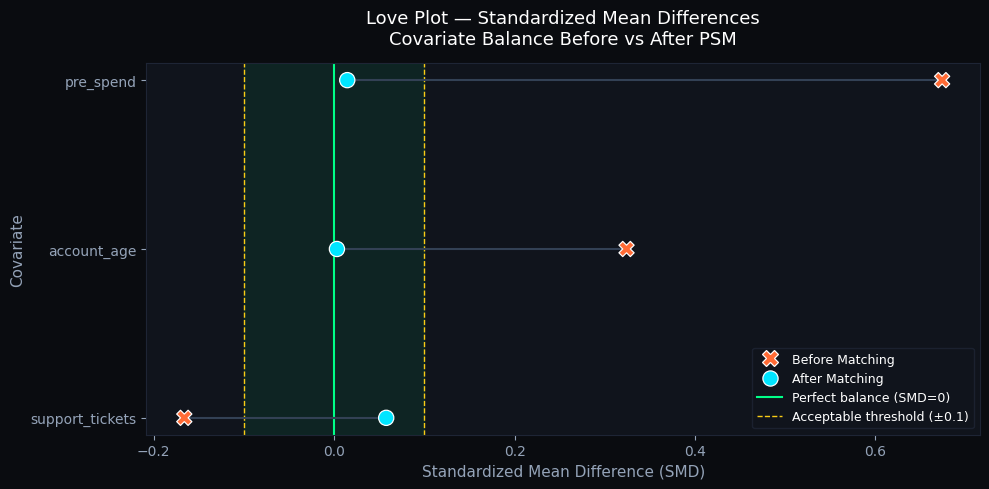


   SMD Summary — Before vs After Matching
  Covariate              Before     After   Balanced?
----------------------------------------------------
  pre_spend              0.6740    0.0145           ✅
  account_age            0.3241    0.0031           ✅
  support_tickets       -0.1661    0.0577           ✅


In [28]:
# ─────────────────────────────────────────────
# Setup: define df_unmatched and df_matched
# ─────────────────────────────────────────────
df_unmatched = df.copy()
df_matched   = matched_df.copy()

covariates = ['pre_spend', 'account_age', 'support_tickets']

# ─────────────────────────────────────────────
# Standardized Mean Difference (SMD) function
# SMD = (mean_treated - mean_control) / SD_pooled
# ─────────────────────────────────────────────
def compute_smd(data, covariates):
    treated   = data[data['subscriber'] == 1]
    untreated = data[data['subscriber'] == 0]
    smds = {}
    for col in covariates:
        mean_t = treated[col].mean()
        mean_c = untreated[col].mean()
        sd_pooled = np.sqrt(
            (treated[col].var() + untreated[col].var()) / 2
        )
        smds[col] = (mean_t - mean_c) / sd_pooled
    return smds

smd_before = compute_smd(df_unmatched, covariates)
smd_after  = compute_smd(df_matched,   covariates)

# ─────────────────────────────────────────────
# Build plotting DataFrame
# ─────────────────────────────────────────────
plot_df = pd.DataFrame({
    'Covariate' : covariates * 2,
    'SMD'       : [smd_before[c] for c in covariates] +
                  [smd_after[c]  for c in covariates],
    'Stage'     : ['Before Matching'] * len(covariates) +
                  ['After Matching']  * len(covariates)
})

# ─────────────────────────────────────────────
# Love Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0a0c10")
ax.set_facecolor("#10141c")

palette = {'Before Matching': '#ff6b35', 'After Matching': '#00e5ff'}

sns.scatterplot(
    data=plot_df, y='Covariate', x='SMD',
    hue='Stage', style='Stage',
    markers={'Before Matching': 'X', 'After Matching': 'o'},
    s=120, palette=palette, ax=ax, zorder=3
)

# Connect before/after with lines per covariate
for cov in covariates:
    x_before = smd_before[cov]
    x_after  = smd_after[cov]
    ax.plot([x_before, x_after], [cov, cov],
            color='#334155', linewidth=1.5, zorder=2)

# Threshold bands
ax.axvline(0,     color='#00ff88', linewidth=1.5, linestyle='-',  zorder=1, label='Perfect balance (SMD=0)')
ax.axvline( 0.1,  color='#facc15', linewidth=1,   linestyle='--', zorder=1, label='Acceptable threshold (±0.1)')
ax.axvline(-0.1,  color='#facc15', linewidth=1,   linestyle='--', zorder=1)
ax.axvspan(-0.1, 0.1, alpha=0.07, color='#00ff88', zorder=0)

# Styling
ax.set_title("Love Plot — Standardized Mean Differences\nCovariate Balance Before vs After PSM",
             color='white', fontsize=13, pad=14)
ax.set_xlabel("Standardized Mean Difference (SMD)", color='#94a3b8', fontsize=11)
ax.set_ylabel("Covariate", color='#94a3b8', fontsize=11)
ax.tick_params(colors='#94a3b8')
for spine in ax.spines.values():
    spine.set_edgecolor('#1e2535')

legend = ax.legend(facecolor='#10141c', edgecolor='#1e2535',
                   labelcolor='white', fontsize=9)
plt.tight_layout()
plt.savefig("love_plot.png", dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

# ─────────────────────────────────────────────
# SMD Summary Table
# ─────────────────────────────────────────────
print("\n" + "=" * 52)
print("   SMD Summary — Before vs After Matching")
print("=" * 52)
print(f"  {'Covariate':<20} {'Before':>8}  {'After':>8}  {'Balanced?':>10}")
print("-" * 52)
for cov in covariates:
    b = smd_before[cov]
    a = smd_after[cov]
    balanced = "✅" if abs(a) < 0.1 else "❌"
    print(f"  {cov:<20} {b:>8.4f}  {a:>8.4f}  {balanced:>10}")